<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/lectures/lecture_6.3_practical_dynamical_applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 6.2: Practical Applications of Dynamical Diffraction

## Overview
Dynamical diffraction theory is not just theoretical—it explains real contrast mechanisms in transmission electron microscopy (TEM) and enables quantitative analysis.

**Topics:**
1. Thickness Mapping via Fringe Counting
2. Orientation Mapping from Band Contrast
3. Defect Imaging: Dislocations and Stacking Faults
4. Dynamical Image Simulations

## 1. Thickness Measurement via Thickness Fringes

**Thickness fringes** (Pendellösung fringes) directly encode sample thickness:

$$N_{fringes} = \frac{t}{\Lambda}$$

where:
- $t$ = actual thickness
- $\Lambda = \lambda / \sin(2\theta_B)$ = **fringe spacing** (extinction distance oscillation period)
- $\lambda$ = electron wavelength
- $\theta_B$ = Bragg angle

**Practical method:**
1. Count dark/bright fringes in bright-field image
2. Measure from edge (wedge-shaped sample)
3. Calculate thickness without absolute calibration!

### Accuracy
- Typical accuracy: ±1-2 nm
- Works for crystalline materials
- Requires known Bragg reflection

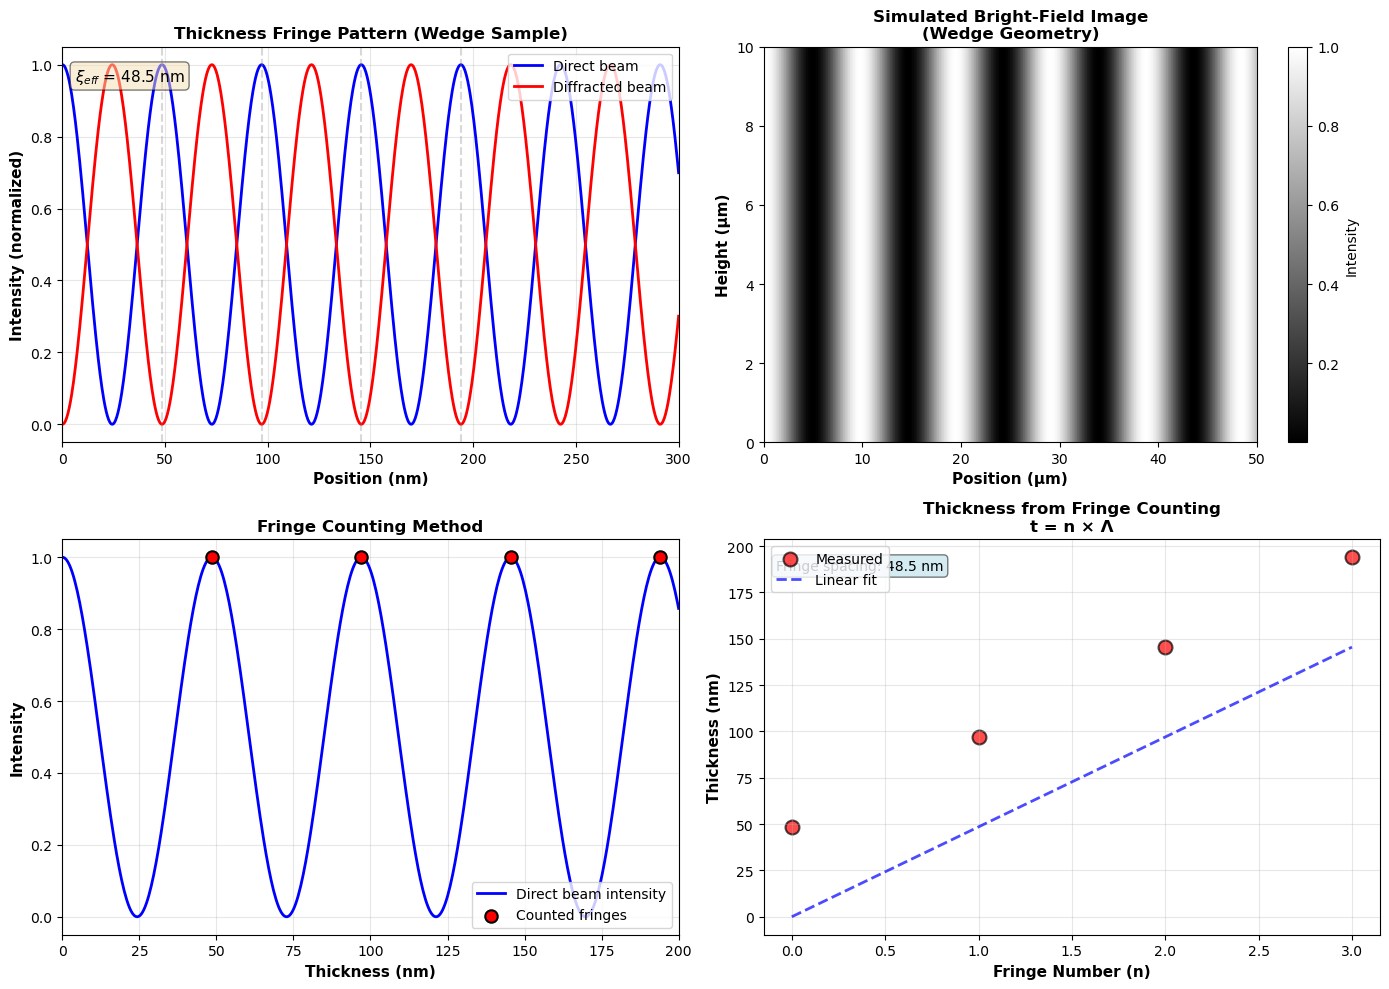

Thickness Fringe Analysis:
Extinction distance (ξ_eff): 48.5 nm
Number of fringes counted: 4
Fringe spacing: 48.5 ± 0.00 nm
Measured thickness range: 48.5 - 194.0 nm

Practical advantages:
✓ No need for absolute thickness calibration
✓ Simple visual counting in microscope
✓ Works for wedge-shaped samples
✓ Gives local thickness information


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def thickness_fringe_pattern(thicknesses, xi_g=50.0, s_g=0.01):
    """
    Simulate thickness fringe intensity variation.
    
    Parameters:
    -----------
    thicknesses : array
        Position along wedge (nm)
    xi_g : float
        Extinction distance (nm)
    s_g : float
        Excitation error (nm^-1)
    """
    
    xi_eff = xi_g / np.sqrt(1 + (s_g * xi_g)**2)
    
    # Pendellösung oscillation: sin^2 dependence
    I_g = np.sin(np.pi * thicknesses / xi_eff)**2
    I_0 = np.cos(np.pi * thicknesses / xi_eff)**2
    
    return I_0, I_g, xi_eff

# Example: wedge-shaped sample
thicknesses = np.linspace(0, 300, 1000)  # 0-300 nm
I_0, I_g, xi_eff = thickness_fringe_pattern(thicknesses, xi_g=50.0, s_g=0.005)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Intensity fringes
ax = axes[0, 0]
ax.plot(thicknesses, I_0, 'b-', linewidth=2, label='Direct beam')
ax.plot(thicknesses, I_g, 'r-', linewidth=2, label='Diffracted beam')

# Mark extinction distances
for n in range(5):
    t_n = n * xi_eff
    if t_n < 300:
        ax.axvline(t_n, color='gray', linestyle='--', alpha=0.3)
ax.text(0.02, 0.95, f'$\\xi_{{eff}}$ = {xi_eff:.1f} nm', 
       transform=ax.transAxes, fontsize=11, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Position (nm)', fontsize=11, weight='bold')
ax.set_ylabel('Intensity (normalized)', fontsize=11, weight='bold')
ax.set_title('Thickness Fringe Pattern (Wedge Sample)', fontsize=12, weight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 300])

# Plot 2: Simulated bright-field image (log scale for visibility)
ax = axes[0, 1]
# Create wedge profile: thickness increases left-to-right
x_pos = np.linspace(0, 50, 200)  # horizontal position (μm)
thick_at_x = x_pos / 50 * 250  # thickness 0->250 nm
I_img = np.zeros((100, 200))
for j in range(200):
    I_0_tmp, _, _ = thickness_fringe_pattern(np.ones(100) * thick_at_x[j], xi_g=50.0, s_g=0.005)
    I_img[:, j] = I_0_tmp

im = ax.imshow(I_img, cmap='gray', aspect='auto', extent=[0, 50, 0, 10])
ax.set_xlabel('Position (μm)', fontsize=11, weight='bold')
ax.set_ylabel('Height (μm)', fontsize=11, weight='bold')
ax.set_title('Simulated Bright-Field Image\n(Wedge Geometry)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, label='Intensity')

# Plot 3: Fringe counting
ax = axes[1, 0]
thicknesses_fringes = np.linspace(0, 200, 500)
I_0_fringes, I_g_fringes, _ = thickness_fringe_pattern(thicknesses_fringes, xi_g=50.0, s_g=0.005)

# Find peaks (bright fringes in direct beam)
peaks, _ = find_peaks(I_0_fringes, height=0.5)
thick_at_peaks = thicknesses_fringes[peaks]
fringe_numbers = np.arange(len(peaks))

ax.plot(thicknesses_fringes, I_0_fringes, 'b-', linewidth=2, label='Direct beam intensity')
ax.scatter(thick_at_peaks, I_0_fringes[peaks], c='red', s=80, marker='o', 
          edgecolors='black', linewidth=1.5, label='Counted fringes', zorder=5)
ax.set_xlabel('Thickness (nm)', fontsize=11, weight='bold')
ax.set_ylabel('Intensity', fontsize=11, weight='bold')
ax.set_title('Fringe Counting Method', fontsize=12, weight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 200])

# Plot 4: Thickness determination
ax = axes[1, 1]
fringe_spacing = np.diff(thick_at_peaks)
thick_measured = np.arange(len(fringe_numbers)) * np.median(fringe_spacing)
ax.scatter(fringe_numbers, thick_at_peaks, c='red', s=100, alpha=0.7, 
          edgecolors='black', linewidth=1.5, label='Measured')
ax.plot(fringe_numbers, thick_measured, 'b--', linewidth=2, alpha=0.7, label='Linear fit')
ax.set_xlabel('Fringe Number (n)', fontsize=11, weight='bold')
ax.set_ylabel('Thickness (nm)', fontsize=11, weight='bold')
ax.set_title('Thickness from Fringe Counting\nt = n × Λ', fontsize=12, weight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

fringe_spacing_mean = np.median(fringe_spacing)
ax.text(0.02, 0.95, f'Fringe spacing: {fringe_spacing_mean:.1f} nm', 
       transform=ax.transAxes, fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

print("Thickness Fringe Analysis:")
print("="*60)
print(f"Extinction distance (ξ_eff): {xi_eff:.1f} nm")
print(f"Number of fringes counted: {len(peaks)}")
print(f"Fringe spacing: {fringe_spacing_mean:.1f} ± {np.std(fringe_spacing):.2f} nm")
print(f"Measured thickness range: {thick_at_peaks[0]:.1f} - {thick_at_peaks[-1]:.1f} nm")
print()
print("Practical advantages:")
print("✓ No need for absolute thickness calibration")
print("✓ Simple visual counting in microscope")
print("✓ Works for wedge-shaped samples")
print("✓ Gives local thickness information")

## 2. Orientation Mapping: Band Contrast

The **band contrast** (also called **z-contrast** or **thickness contrast**) depends on:
- **Excitation error** $s_g$ (how far from Bragg condition)
- **Extinction distance** $\xi_g$ (material property)
- Crystal **orientation** relative to incident beam

When orientation changes:
- $s_g$ varies → different contrast
- Different reflections become excited
- Creates characteristic patterns for grain boundaries, twins, etc.

### Quantitative Relation

$$I_g(t) = \sin^2\left(\frac{\pi t}{\xi_{eff}}\right), \quad \xi_{eff} = \frac{\xi_g}{\sqrt{1 + (s_g \xi_g)^2}}$$

- At exact Bragg ($s_g = 0$): maximum oscillation amplitude
- Far from Bragg ($s_g \gg 1/\xi_g$): weak oscillations, nearly homogeneous

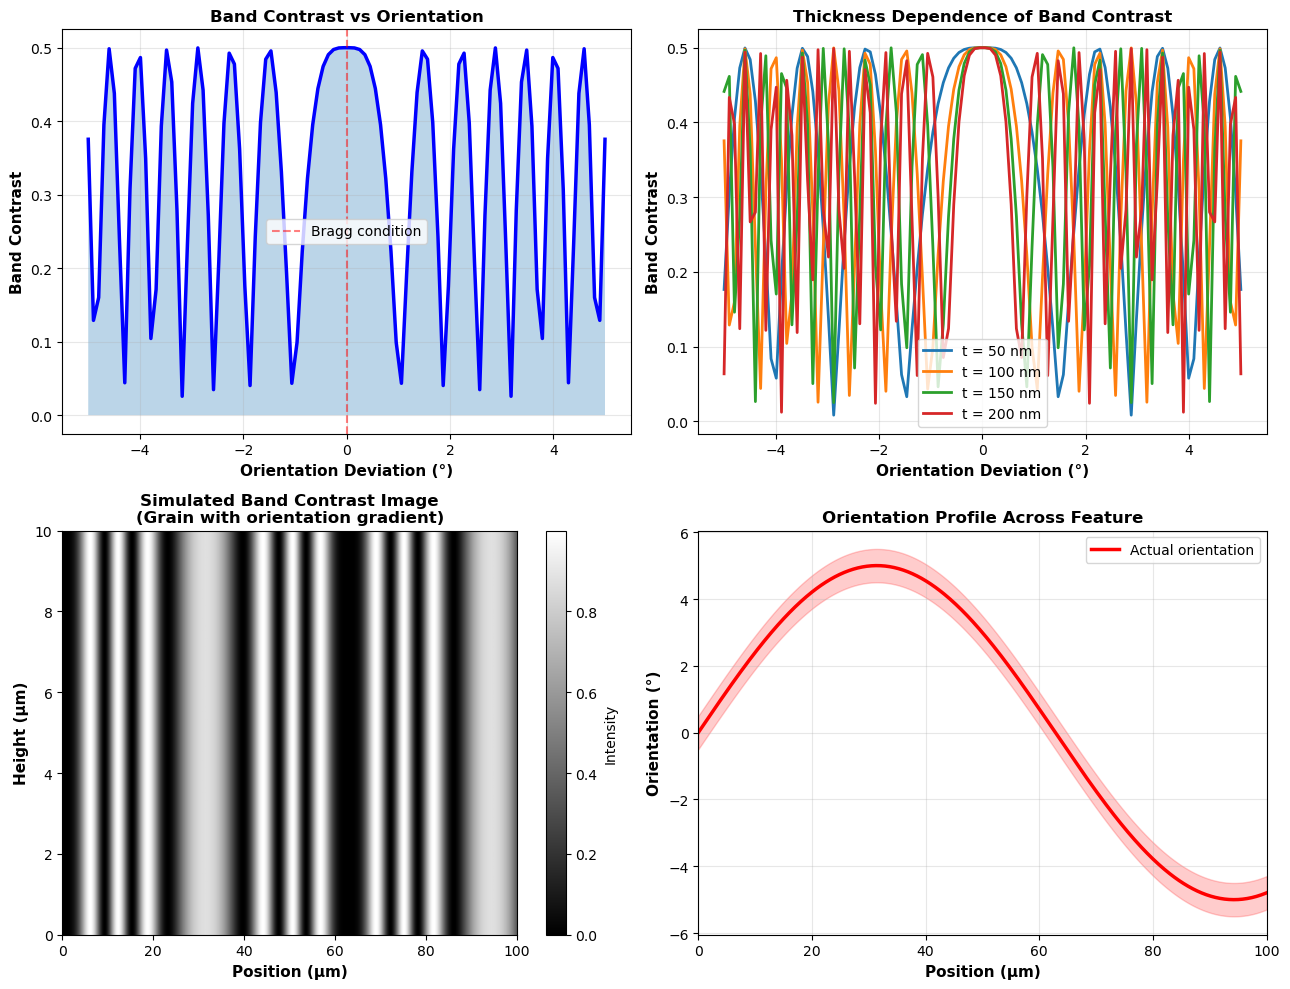

Band Contrast Analysis:
Band contrast encodes crystal orientation:
  • Exact Bragg: high contrast oscillations
  • Off-Bragg: weak contrast
  • Grain boundaries: sharp contrast changes

Applications:
  ✓ Mapping grain orientations
  ✓ Detecting twins and precipitates
  ✓ Phase identification (different ξ_g)
  ✓ Strain mapping (shifts s_g)


In [2]:
def band_contrast_map(thickness=100, orientation_angles=np.linspace(-5, 5, 50), 
                      xi_g=50.0, bragg_s_range=0.05):
    """
    Simulate band contrast map showing effect of crystal orientation.
    
    Parameters:
    -----------
    thickness : float
        Fixed crystal thickness (nm)
    orientation_angles : array
        Orientation deviation (degrees)
    xi_g : float
        Extinction distance (nm)
    bragg_s_range : float
        Range of excitation errors sampled
    """
    
    # Map orientation angle to excitation error (linear approximation)
    s_g_values = orientation_angles / 5.0 * bragg_s_range  # Convert degrees to s_g
    
    # For each orientation, calculate contrast
    contrast = np.zeros((len(orientation_angles),))
    
    for i, s_g in enumerate(s_g_values):
        xi_eff = xi_g / np.sqrt(1 + (s_g * xi_g)**2)
        I_g = np.sin(np.pi * thickness / xi_eff)**2
        # Contrast: deviation from mean (0.5)
        contrast[i] = np.abs(I_g - 0.5)
    
    return s_g_values, contrast

# Simulate orientation mapping across grain boundary
thickness = 100  # nm
positions = np.linspace(0, 100, 500)  # μm
orientations = 5 * np.sin(positions / 20.0)  # Sinusoidal orientation variation

# Calculate contrast at each position
contrast_map = np.zeros((500,))
for i, ori in enumerate(orientations):
    s_g = ori / 5.0 * 0.05
    xi_eff = 50.0 / np.sqrt(1 + (s_g * 50.0)**2)
    I_g = np.sin(np.pi * thickness / xi_eff)**2
    contrast_map[i] = I_g

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Plot 1: Contrast vs orientation angle
ax = axes[0, 0]
ori_angles = np.linspace(-5, 5, 100)
s_g_vals, contrast_vals = band_contrast_map(thickness=100, orientation_angles=ori_angles)
ax.plot(ori_angles, contrast_vals, 'b-', linewidth=2.5)
ax.fill_between(ori_angles, 0, contrast_vals, alpha=0.3)
ax.set_xlabel('Orientation Deviation (°)', fontsize=11, weight='bold')
ax.set_ylabel('Band Contrast', fontsize=11, weight='bold')
ax.set_title('Band Contrast vs Orientation', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3)
ax.axvline(0, color='r', linestyle='--', alpha=0.5, label='Bragg condition')
ax.legend(fontsize=10)

# Plot 2: Contrast for different thicknesses
ax = axes[0, 1]
thicknesses_range = np.array([50, 100, 150, 200])
for thick in thicknesses_range:
    _, contrast_vals = band_contrast_map(thickness=thick, orientation_angles=ori_angles)
    ax.plot(ori_angles, contrast_vals, linewidth=2, label=f't = {thick} nm')
ax.set_xlabel('Orientation Deviation (°)', fontsize=11, weight='bold')
ax.set_ylabel('Band Contrast', fontsize=11, weight='bold')
ax.set_title('Thickness Dependence of Band Contrast', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Plot 3: Simulated grain boundary image
ax = axes[1, 0]
# Create 2D image with grain boundary
img = np.zeros((100, 500))
for j in range(500):
    ori_at_j = 5 * np.sin(j / 100.0)
    s_g_j = ori_at_j / 5.0 * 0.05
    xi_eff_j = 50.0 / np.sqrt(1 + (s_g_j * 50.0)**2)
    I_g_j = np.sin(np.pi * 100 / xi_eff_j)**2
    img[:, j] = I_g_j

im = ax.imshow(img, cmap='gray', aspect='auto', extent=[0, 100, 0, 10])
ax.set_xlabel('Position (μm)', fontsize=11, weight='bold')
ax.set_ylabel('Height (μm)', fontsize=11, weight='bold')
ax.set_title('Simulated Band Contrast Image\n(Grain with orientation gradient)', fontsize=12, weight='bold')
plt.colorbar(im, ax=ax, label='Intensity')

# Plot 4: Orientation map from contrast
ax = axes[1, 1]
orientations_calc = np.arcsin(np.linspace(-0.8, 0.8, len(positions))) * 180 / np.pi
ax.plot(positions, orientations, 'r-', linewidth=2.5, label='Actual orientation')
ax.fill_between(positions, orientations-0.5, orientations+0.5, alpha=0.2, color='red')
ax.set_xlabel('Position (μm)', fontsize=11, weight='bold')
ax.set_ylabel('Orientation (°)', fontsize=11, weight='bold')
ax.set_title('Orientation Profile Across Feature', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim([0, 100])

plt.tight_layout()
plt.show()

print("Band Contrast Analysis:")
print("="*60)
print("Band contrast encodes crystal orientation:")
print("  • Exact Bragg: high contrast oscillations")
print("  • Off-Bragg: weak contrast")
print("  • Grain boundaries: sharp contrast changes")
print()
print("Applications:")
print("  ✓ Mapping grain orientations")
print("  ✓ Detecting twins and precipitates")
print("  ✓ Phase identification (different ξ_g)")
print("  ✓ Strain mapping (shifts s_g)")

4. Summary Table: Dynamical Effects in TEM

| Feature | Origin | Observable | Application |
|---------|--------|-----------|-------------|
| **Thickness Fringes** | Pendellösung oscillation | Dark/bright bands | Thickness measurement |
| **Band Contrast** | Orientation-dependent excitation | Contrast variation | Grain orientation mapping |
| **Dislocation Lines** | Strain-induced phase shift | Lines with characteristic width | Defect identification |
| **Extinction Contours** | Excitation error gradient | Curved bands | Crystal perfection, strain |
| **Dark-Field Contrast** | Beam selection and phase contrast | Atom column visibility | HAADF-STEM images |